# 키워드 확정 루프 — 증거 기반 (흥행 *유발* 검증)

> 목적: 파라미터 조정 → 나온 키워드가 **진짜 흥행을 유발**하는지 4축 증거로 확인 → 확정 → 대시보드 연결.
> 4축: ① 통계(purity·성공률) ② **인과(Δprob: 더하면 성공확률 오르나)** ③ 실증(실매출) ④ 지지도.

```
[튜닝] EngineConfig 임계 조정 → 장부 재생성
   ↓
[검토] evidence_table 로 Δprob·매출 스캔 → 단일 키워드 drill-down
   ↓  (반복)
[확정] keyword_final.csv 저장 (include/tag + 증거)
   ↓
[연결] python -m scripts.export_dashboard → dashboard.html 반영
```
**당신이 하는 일**: 셀 돌리며 Δprob≤0인 가짜 killer 골라내고, 임계 조정해 재확인 → 마지막에 CSV 저장.

In [45]:
import os, sys

def _find_repo_root(start):
    """cwd가 repo 어디에 있든 src/eval + experiments 가진 루트를 위로 탐색 (커널 cwd 무관)."""
    p = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(p, "src", "eval")) and os.path.isdir(os.path.join(p, "experiments")):
            return p
        parent = os.path.dirname(p)
        if parent == p:
            return None
        p = parent

ROOT = _find_repo_root(os.getcwd())
assert ROOT, f"repo 루트 못 찾음 (cwd={os.getcwd()})"
if ROOT not in sys.path: sys.path.insert(0, ROOT)
os.chdir(ROOT)
import numpy as np, pandas as pd
pd.set_option("display.max_rows", 200)
from src.eval.md.engine import MDEngine, EngineConfig
from src.eval.md import inspector as I
from src.eval.md.inspector import keyword_evidence, evidence_table, ledger_keywords, export_keyword_final

MODEL = "v2_sweepA"   # "v2_sweepA"(최종 채택) | "exp47"  (장부는 모델 거의 불변)
print("model:", MODEL)

model: v2_sweepA


## 1. 엔진 로드 + 장부 (파라미터는 EngineConfig)

In [46]:
# ★ 파라미터 튜닝 지점 — 값 바꾸고 이 셀부터 다시 실행하면 장부가 바뀜
CFG = (EngineConfig.exp47() if MODEL=="exp47" else EngineConfig.v2_sweepA())
CFG.killer_purity = 0.50   # killer purity 하한 (base 0.238 위)
CFG.killer_top_q  = 0.75   # Score_succ 상위 25%
CFG.mine_purity   = 0.15   # mine purity 상한
CFG.hub_top_q     = 0.80   # Hub_Score 상위 20%
CFG.hub_balance_eps = 0.15 # |purity-base| 균형 게이트

eng = MDEngine(CFG).run_single_inference(); eng.build_mass(); lg = eng.build_ledger("full")
print(f"killer {len(lg.killer)} / mine {len(lg.mine)} / hub {len(lg.hub)} / neutral {eng.cache['K']-len(lg.killer|lg.mine|lg.hub)}")

killer 62 / mine 131 / hub 144 / neutral 1726


## 1.5 파라미터 검증 + WoE/att_lift 필터 — 분류 확정

장부 파라미터 5종(killer_purity 0.50 · mine_purity 0.15 · hub_eps 0.15 · killer/mine_q 0.75 · hub_q 0.80)은 분포 검증 완료 → **값 불변, "임의값 → data-justified"** (근거 플롯: 맨 끝 부록).

그 위에 **att_lift(모델 관점) + WoE(통계 관점, 희소성 무편향)** 동시충족 필터로 노이즈 제거:
- `killer` = base ∧ att_lift>1 ∧ **WoE>0** ∧ supp_f>0  (소주·효모 등 실패편향 제거)
- `mine`   = base ∧ **WoE<0** ∧ supp_s>0  (통계 중립 제거)
- `hub`    = base ∧ att_lift<1.5 ∧ **|WoE|<0.5**  (균형 게이트)

→ killer 62→48 · mine 131→84 · hub 144→79 (coverage ~10%). 상세: 카톡 md `2026-06-22_keyword-ledger-param-verification-woe-filter`.

> **WoE** = ln( (성공제품 중 보유율) / (실패제품 중 보유율) ). >0 성공신호 / <0 실패신호. count 기반이라 att_lift의 희소성 편향이 없다.
> 이 셀이 만드는 `df_kw`(태그 + woe·att_lift)와 `killers_woe/mines_woe/hubs_woe`가 이후 증거·export의 단일 진실원.

In [47]:
# §1.5 WoE/att_lift 필터 + 빈도보정 + killer 2단등급(B안) — 확정 분류
y = eng.cache["y"]; n_succ = int((y == 1).sum()); n_fail = int((y == 0).sum())
purity_arr = lg.purity
supp_s = lg.support_succ; supp_f = lg.support_fail; supp_all = supp_s + supp_f
hub_score_arr = lg.hub_score
i2k = {v: k for k, v in eng.cache["k2i"].items()}
kw_names = [i2k[i] for i in range(eng.cache["K"])]
att_lift = (lg.score_succ / n_succ) / (lg.score_fail / n_fail + 1e-9)
woe = np.log((supp_s / n_succ + 1e-9) / (supp_f / n_fail + 1e-9))
n_raw = np.bincount(eng.cache["eidx"][("product", "has_kw", "keyword")].numpy()[1], minlength=eng.cache["K"])

elig_k = supp_s >= 3; elig_m = supp_f >= 3; elig_h = supp_all >= 3
k_q75 = np.quantile(lg.score_succ[elig_k], 0.75)
k_q50 = np.quantile(lg.score_succ[elig_k], 0.50)
m_thr = np.quantile(lg.score_fail[elig_m], 0.75)
h_thr = np.quantile(hub_score_arr[elig_h], 0.80)

# killer 2단등급: T1 엄격(purity≥0.50·Q75) / T2 확장(purity≥0.35·Q50). 둘다 WoE>0·supp_f>0·빈도≥3
_kbase = elig_k & (woe > 0) & (supp_f > 0) & (n_raw >= 3)
killer_T1 = _kbase & (purity_arr >= 0.50) & (lg.score_succ >= k_q75)
killer_T2 = _kbase & (purity_arr >= 0.35) & (lg.score_succ >= k_q50) & ~killer_T1
killer_woe = killer_T1 | killer_T2

mine_woe = elig_m & (purity_arr <= 0.15) & (lg.score_fail >= m_thr) & (woe < 0) & (supp_s > 0) & (n_raw >= 3)
hub_woe  = elig_h & (np.abs(purity_arr - 0.238) < 0.15) & (hub_score_arr >= h_thr) & ~killer_woe & ~mine_woe & (att_lift < 1.5) & (np.abs(woe) < 0.5)

df_kw = pd.DataFrame({"keyword": kw_names, "purity": purity_arr, "score_succ": lg.score_succ,
                      "score_fail": lg.score_fail, "hub_score": hub_score_arr, "빈도": n_raw,
                      "supp_s": supp_s, "supp_f": supp_f, "supp_all": supp_all,
                      "woe": woe, "att_lift": att_lift})
df_kw["tag"] = "neutral"; df_kw["grade"] = ""
df_kw.loc[killer_woe, "tag"] = "killer"
df_kw.loc[killer_T1, "grade"] = "T1"; df_kw.loc[killer_T2, "grade"] = "T2"
df_kw.loc[mine_woe, "tag"] = "mine"; df_kw.loc[mine_woe, "grade"] = "T1"
df_kw.loc[hub_woe, "tag"] = "hub"

killers_woe = df_kw.loc[df_kw.tag == "killer", "keyword"].tolist()
mines_woe   = df_kw.loc[df_kw.tag == "mine", "keyword"].tolist()
hubs_woe    = df_kw.loc[df_kw.tag == "hub", "keyword"].tolist()
print("확정 분류:", df_kw["tag"].value_counts().to_dict())
print(f"  killer 등급: T1 {int(killer_T1.sum())} + T2 {int(killer_T2.sum())} = {int(killer_woe.sum())} (T1 엄격·T2 확장)")
print(f"  mine {int(mine_woe.sum())} / hub {int(hub_woe.sum())}(내부게이트)")

확정 분류: {'neutral': 1790, 'killer': 124, 'hub': 79, 'mine': 70}
  killer 등급: T1 33 + T2 91 = 124 (T1 엄격·T2 확장)
  mine 70 / hub 79(내부게이트)


## 2. 증거 스캔 — killer가 진짜 흥행을 유발하나 (Δprob)

In [48]:
# killer(WoE확정) Δprob 증거 — 진짜 흥행 유발(Δ>0) vs 상관만(Δ≤0)
tbl = evidence_table(eng, killers_woe).sort_values("delta_prob_mean", ascending=False)
print(f"killer(WoE) {len(tbl)}개 중 Δ>0(진짜유발) {(tbl['delta_prob_mean']>0).sum()} / Δ≤0(상관만) {(tbl['delta_prob_mean']<=0).sum()}")
display(tbl)

killer(WoE) 124개 중 Δ>0(진짜유발) 70 / Δ≤0(상관만) 54


,keyword,tag,성공률,base_rate,purity,balance,support_succ,support_fail,delta_prob_mean,delta_prob_pos_rate,매출중앙값,hub_score
40,미역,neutral,0.571,0.238,0.571,0.334,4,3,0.1557,1.00,511934.0,-0.784
114,하와이,killer,0.833,0.238,0.833,0.596,10,2,0.1292,1.00,NaN,-0.865
115,한정,killer,0.596,0.238,0.579,0.342,107,76,0.1070,1.00,2082296.0,3.391
6,고창,killer,0.800,0.238,0.800,0.562,4,1,0.1059,1.00,6686735.0,1.546
44,발효,neutral,0.714,0.238,0.357,0.119,5,5,0.0972,1.00,3691198.0,-0.120
52,빈츠,killer,0.800,0.238,0.800,0.562,4,1,0.0863,1.00,6592740.0,0.770
15,대게,neutral,0.600,0.238,0.600,0.362,3,2,0.0846,1.00,13234528.0,0.069
25,라이트,neutral,0.571,0.238,0.571,0.334,4,3,0.0825,1.00,34449.0,-0.545
101,큐브,neutral,0.571,0.238,0.571,0.334,4,3,0.0816,1.00,1496196.0,0.270
96,커스터드,killer,0.611,0.238,0.511,0.273,69,133,0.0811,1.00,3019584.0,2.959


In [49]:
# mine / hub (WoE확정) 도 같은 방식
print("── MINE (Δprob<0 이어야 진짜 악재) ──"); display(evidence_table(eng, mines_woe).sort_values("delta_prob_mean"))
print("── HUB (balance 작아야 진짜 일반어) ──"); display(evidence_table(eng, hubs_woe).sort_values("balance"))

── MINE (Δprob<0 이어야 진짜 악재) ──


,keyword,tag,성공률,base_rate,purity,balance,support_succ,support_fail,delta_prob_mean,delta_prob_pos_rate,매출중앙값,hub_score
31,시나몬,mine,0.000,0.238,0.099,0.139,20,87,-0.1495,0.00,779334.0,0.315
32,시원,mine,0.167,0.238,0.125,0.113,46,200,-0.1055,0.00,866134.0,-0.357
53,찌개,mine,0.000,0.238,0.063,0.175,1,30,-0.1047,0.00,33000.0,-1.505
44,와인,mine,0.097,0.238,0.048,0.189,29,272,-0.0967,0.00,12853750.0,-1.691
40,에스프레소,mine,0.083,0.238,0.042,0.196,1,13,-0.0945,0.00,2696614.0,-1.726
50,제육,mine,0.130,0.238,0.065,0.173,6,41,-0.0917,0.00,996603.0,-1.085
54,청,mine,0.000,0.238,0.068,0.169,13,85,-0.0898,0.00,9350.0,-1.581
1,갈비,mine,0.191,0.238,0.096,0.142,9,38,-0.0798,0.00,14897548.0,-1.470
5,다이어트,mine,0.123,0.238,0.107,0.131,14,105,-0.0789,0.07,2487364.0,-0.442
30,순대,mine,0.111,0.238,0.148,0.090,2,10,-0.0767,0.00,1698190.0,-2.680


── HUB (balance 작아야 진짜 일반어) ──


,keyword,tag,성공률,base_rate,purity,balance,support_succ,support_fail,delta_prob_mean,delta_prob_pos_rate,매출중앙값,hub_score
58,토스트,hub,0.235,0.238,0.235,0.003,4,13,0.0037,0.73,396089.0,1.206
57,키치,hub,NaN,0.238,0.241,0.003,13,41,-0.0300,0.20,NaN,1.637
22,맛,hub,0.333,0.238,0.244,0.006,29,88,0.0055,0.87,7660100.0,1.846
69,피자,hub,0.204,0.238,0.245,0.007,33,103,-0.0448,0.13,5889520.0,1.925
49,젤리,hub,0.314,0.238,0.246,0.008,126,270,-0.0005,0.73,2946812.0,3.678
42,스파게티,hub,0.154,0.238,0.246,0.008,8,18,-0.0538,0.00,5217196.0,2.954
8,김밥,hub,0.318,0.238,0.229,0.009,98,207,-0.0115,0.33,15445631.0,1.172
2,간식,hub,0.338,0.238,0.229,0.009,968,2332,0.0154,1.00,NaN,1.860
15,도시락,hub,0.241,0.238,0.249,0.011,406,1048,-0.0538,0.00,7858170.0,2.708
14,도라야끼,hub,0.250,0.238,0.250,0.012,1,3,-0.0406,0.07,5362534.0,5.087


In [51]:
import importlib, src.eval.md.review
importlib.reload(src.eval.md.review)

<module 'src.eval.md.review' from 'c:\\Users\\송정현\\Documents\\Projects\\박재홍교수님세미나\\Projects\\20기\\7eleven_npd_framework\\src\\eval\\md\\review.py'>

## 2.5 질적 리뷰 — 카테고리 카운트 + 키워드별 증거 (판정이 실제 맞나)

분류(WoE+빈도)는 관찰, 검증은 개입(Δprob). 표는 `keyword·빈도·purity·WoE·단독·Δ·판정·예시제품`으로 *눈검사*한다.

**근거 4축** (왜 killer인가 — 서로 다른 렌즈로 교차검증):
- **purity**(어텐션) 성공 치우침 · **WoE**(통계 카운트) 성공 출현비 · **단독성공률**(raw) 혼자 실력 = **관찰**(단일추론)
- **Δprob**(개입) 넣으면 오르나 = **인과 검증**(재추론)

**★ killer 판정 조건** (노이즈밴드 ±0.01 ≈ 2·SE):

| 판정 | 조건 | 의미 |
|---|---|---|
| **확실** | Δ > +0.01 | 넣으면 확실히 오름 (유발 ✓) |
| **불명확(노이즈)** | −0.01 ≤ Δ ≤ +0.01 | 노이즈 안쪽, 0과 구분 불가 |
| **조건부killer(IP)** | Δ < −0.01 ∧ Δcond > +0.01 | 혼자선 안 오르나 IP 있으면 오름 (공룡류) |
| **가짜(강등)** | Δ < −0.01 ∧ Δcond ≤ +0.01 | IP로도 안 오름 = 상관만 (강등) |

> ★ 관찰(purity·WoE·단독)이 높아도 **Δ(개입)가 낮으면 가짜**. 관찰↔개입 불일치가 핵심 신호 (공룡: purity 0.92인데 Δ −0.014).
> **mine 판정**: Δ<−0.01 진짜악재 / −0.01~+0.01 불명확 / Δ>+0.01 통계만(의심).  **매개**: delta_pos≥0.7(거의 전캐리어 +).
> **빈도** = 직접 has_kw 제품 수. <3이면 소표본 거품(공주 n=1)이라 분류 단계서 제외됨.

In [52]:
# §2.5 질적 리뷰 — review_killers Δprob 수십초 + 의심키워드 조건부Δ
from src.eval.md import review as R

kdf = R.review_killers(eng, df_kw)
mdf = R.review_mine_hub(eng, df_kw, "mine")
hdf = R.review_mine_hub(eng, df_kw, "hub")
n_neu = int((df_kw.tag == "neutral").sum())

print("[카테고리/판정별 개수]"); display(R.review_summary(kdf, mdf, hdf, n_neu))

# keyword | 빈도 | purity | WoE | 단독 | Δ | Δcond | 판정 | 예시제품  (판정 조건은 위 마크다운 표)
print("\n[killer 질적표]")
display(kdf[["keyword", "빈도", "purity", "woe", "단독성공률", "delta", "delta_cond", "판정", "예시제품"]])
print("\n[mine 질적표]")
display(mdf[["keyword", "빈도", "purity", "woe", "단독성공률", "delta", "판정", "예시제품"]])
print("[hub — 내부 게이트(출력 X)]")
display(hdf[["keyword", "purity", "balance", "단독성공률", "판정"]])

[카테고리/판정별 개수]


,카테고리,판정,개수
0,killer,killer_확실,61
1,killer,가짜(강등),35
2,killer,killer_불명확(노이즈),23
3,killer,조건부killer(IP),5
4,mine,진짜 악재(Δ<0),63
5,mine,통계만(의심),4
6,mine,불명확,3
7,hub,진짜 일반어,79
8,neutral,-,1790



[killer 질적표]


,keyword,빈도,purity,woe,단독성공률,delta,delta_cond,판정,예시제품
0,미역,7,0.571,1.452,0.571,0.1557,NaN,killer_확실,썬푸드)소칸미역줄기30g(성공) / PB)럭히밥든든미역꾹밥225g(성공) / 롯데)...
1,하와이,12,0.833,2.774,0.833,0.1292,NaN,killer_확실,하와이안쉬림프김밥(성공) / 하와이안코코넛쉬림프(성공) / 하와이안스팸무스비(성공)
2,한정,171,0.579,1.507,0.596,0.1070,NaN,killer_확실,가나디바나나우유(성공) / PB)K리그슛!크림빵105g(성공) / PB)K리그슛!소...
3,고창,5,0.800,2.551,0.800,0.1059,NaN,killer_확실,롯데)빈츠고창꿀고구마102g(성공) / 롯데)카스타드고창꿀고구마210g(성공) / ...
4,발효,7,0.357,1.165,0.714,0.0972,NaN,killer_확실,삼립)주종발효카스타드크림빵105g(성공) / 삼립)주종발효초코크림소보루85g(성공)...
5,빈츠,5,0.800,2.551,0.800,0.0863,NaN,killer_확실,롯데)빈츠프리미어말차102g(성공) / 롯데)빈츠말차102g(청수당)(성공) / 롯...
6,대게,5,0.600,1.570,0.600,0.0846,NaN,killer_확실,APP예약)울진대게딱지장김밥(실패) / 그린)울진대게딱지장김밥(성공) / 그린)더커...
7,라이트,7,0.571,1.452,0.571,0.0825,NaN,killer_확실,빙그레)부라보바닐라라이트160ml(성공) / 그랜드야쿠르트(실패) / CJ)스팸라이...
8,큐브,7,0.571,1.452,0.571,0.0816,NaN,killer_확실,롯데)이너프홀그레인큐브케이크60g(성공) / 제이탑)큐브쫀득쿠키(후르츠)50g(성공...
9,커스터드,18,0.511,0.508,0.611,0.0811,NaN,killer_확실,부창제과)소금우유호빵(3입)(성공) / 망곰커스터드푸딩(실패) / 엠즈)39저당커스...



[mine 질적표]


,keyword,빈도,purity,woe,단독성공률,delta,판정,예시제품
0,시나몬,12,0.099,-0.306,0.000,-0.1495,진짜 악재(Δ<0),APP)애용이애플&치즈냥샌드(실패) / 메타)레벨스트레이트버번750ml(실패) / ...
1,시원,102,0.125,-0.305,0.167,-0.1055,진짜 악재(Δ<0),엔제이)후루츄(망고맛)90g(성공) / 엔제이)후루츄(딸기맛)90g(성공) / 자이...
2,찌개,23,0.063,-2.237,0.000,-0.1047,진짜 악재(Δ<0),CJ)비비고썰은배추김치1.8kg(실패) / 하림)더미식차돌된장찌개700g(실패) /...
3,와인,300,0.048,-1.074,0.097,-0.0967,진짜 악재(Δ<0),비노)콜미레이터브로드센트럴코스트샤도네이(실패) / CSR)텍스트북나파까버네에디션75...
4,에스프레소,12,0.042,-1.400,0.083,-0.0945,진짜 악재(Δ<0),서울)말차에스프레소200ml(성공) / 커피믹스프레소프라페(실패) / 밀크믹스프레소...
5,제육,46,0.065,-0.757,0.130,-0.0917,진짜 악재(Δ<0),APP예약)맛장우맛자랑 로스트치킨(실패) / APP예약)맛장우맛자랑 반반제육(실패)...
6,청,3,0.068,-0.713,0.000,-0.0898,진짜 악재(Δ<0),1865청뱀띠에디션(실패) / 조닌프로세코750ml(실패) / 직납)더블더블(청귤)...
7,갈비,47,0.096,-0.276,0.191,-0.0798,진짜 악재(Δ<0),맛제일)남도떡갈비삼각(성공) / 맛제일)콘치즈떡갈비김밥(성공) / 그린)맛장우맛자랑...
8,다이어트,106,0.107,-0.850,0.123,-0.0789,진짜 악재(Δ<0),엠즈)39저당커스터드크림롤105g(성공) / 연세)블루베리요거트300ml(성공) /...
9,순대,9,0.148,-0.445,0.111,-0.0767,진짜 악재(Δ<0),PB)장충동고기순대300g(성공) / 쫀득한찰순대(실패) / 육즙고기순대(실패)


[hub — 내부 게이트(출력 X)]


,keyword,purity,balance,단독성공률,판정
0,토스트,0.235,0.003,0.235,진짜 일반어
1,키치,0.241,0.003,NaN,진짜 일반어
2,맛,0.244,0.006,0.333,진짜 일반어
3,피자,0.245,0.007,0.204,진짜 일반어
4,젤리,0.246,0.008,0.314,진짜 일반어
5,스파게티,0.246,0.008,0.154,진짜 일반어
6,김밥,0.229,0.009,0.318,진짜 일반어
7,간식,0.229,0.009,0.338,진짜 일반어
8,도시락,0.249,0.011,0.241,진짜 일반어
9,도라야끼,0.250,0.012,0.250,진짜 일반어


## 2.6 매개/증폭 키워드 + 카테고리별 "왜" (실제 제품 예시 EDA)

killer/mine/hub(성공 *특이성* 축)와 **직교하는 보편 *리프트* 축** = **매개/증폭**.
- 정의: **혼자선 약한데(단독성공률↓) 어디 붙여도 구매력↑(delta_pos≈1.0)**. = "아무 신제품에나 넣으면 +".
- 예: 즉석·허쉬·저당·당충전·트러플·키링 — 성공 특이는 아니나 보편 강화제.
- ★ 증폭후보(튀김·짭조름함 등)가 여기로 분리되면 **killer가 success-특이로 깨끗**해진다.

**각 카테고리 "왜" 근거 = 다른 축**:
- killer: purity·WoE·**Δprob>0(유발)**·단독강도 (`근거` 컬럼) — `kdf`
- mine: purity·WoE·**Δprob<0(악재)** (`근거`) — `mdf`
- 매개: 단독↓·**delta_pos↑(보편)**·purity 균형 (`근거`) — `med`

→ 각 표의 `근거` + `예시제품`(실제 키워드 보유 제품·성공/실패)으로 **판정이 맞는지 눈검사**.

In [53]:
# §2.6 매개/증폭 2단등급 (배치 Δ ~분) + 카테고리별 근거·예시제품
med = R.review_mediator(eng, df_kw, supp_max=400)   # 2단: T1(무조건+) / T2(확장 pos≥0.7)
print(f"매개/증폭: {len(med)}개  (T1 {int((med.grade=='T1').sum())} + T2 {int((med.grade=='T2').sum())})")
display(med[["keyword", "grade", "빈도", "단독성공률", "연결수", "delta_mean", "delta_pos", "근거", "예시제품"]])

# 카테고리별 "왜" — killer/mine 근거 (kdf/mdf는 §2.5)
print("[killer 왜 — 근거·예시]"); display(kdf[["keyword", "판정", "단독성공률", "delta", "근거", "예시제품"]])
print("[mine 왜 — 근거·예시]"); display(mdf[["keyword", "판정", "단독성공률", "delta", "근거", "예시제품"]])

매개/증폭: 79개  (T1 24 + T2 55)


,keyword,grade,빈도,단독성공률,연결수,delta_mean,delta_pos,근거,예시제품
0,즉석,T1,33,0.424,33,0.1136,1.00,단독 0.424(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.1...,최강록의진심)지파이(성공) / 쿡인페이퍼)즉석진라면매운맛(성공) / 혜자로운백미밥(실패)
1,허쉬,T1,25,0.360,25,0.1065,1.00,단독 0.36(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.10...,서주)허쉬초코탑콘크리미아몬드130ml(성공) / 미성)허쉬쿠앤크라운즈96g(실패) ...
2,저당,T1,71,0.338,76,0.0949,1.00,단독 0.338(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.0...,디저트39)저당팥모나카140ml(성공) / 디저트39)저당슈크림모나카140ml(성공...
3,튀김,T1,32,0.344,330,0.0879,1.00,단독 0.344(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.0...,베어스라이스볼(성공) / PB)최강록의리얼웨지감자45g(성공) / 메타몽돈까스정식(성공)
4,야채,T1,20,0.350,20,0.0870,1.00,단독 0.35(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.08...,한도초과)아삭아삭햄야채샌드(성공) / 삼립야채호빵(실패) / CJ)햇반버섯야채죽26...
5,당충전,T1,11,0.273,11,0.0797,1.00,단독 0.273(혼자 약)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.0...,롯데)가나초코바자이언츠기획(4입)(성공) / 티처스)당충전딥초코와플90g(성공) /...
6,트러플,T1,16,0.312,16,0.0763,1.00,단독 0.312(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.0...,롯데)트러플촉촉함박도시락(실패) / 써라클)베노프단백질바(트러플피넛)50g(성공) ...
7,붕어빵,T1,13,0.308,13,0.0726,1.00,단독 0.308(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.0...,엔제이)젤리코카스타드타이야끼150g(5입)(성공) / 붕어꼬리빵3입밤크림(실패) /...
8,멜론,T1,51,0.294,52,0.0704,1.00,단독 0.294(혼자 약)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.0...,PB)자이언츠새로온팅클메론맛60g(성공) / 픽셀리)공룡메론소보로(성공) / 풍림)...
9,캐릭터,T1,11,0.364,172,0.0649,1.00,단독 0.364(혼자 중)·delta_pos 1.0(거의 전캐리어 +)·Δ +0.0...,CJ)1등급훈제대란2구(성공) / 캐치!티니핑)하츄핑라면(성공) / 천하)골든씨씨쉘...


[killer 왜 — 근거·예시]


,keyword,판정,단독성공률,delta,근거,예시제품
0,미역,killer_확실,0.571,0.1557,purity 0.571(성공특이)·WoE +1.45·Δ +0.156(유발✓)·단독 ...,썬푸드)소칸미역줄기30g(성공) / PB)럭히밥든든미역꾹밥225g(성공) / 롯데)...
1,하와이,killer_확실,0.833,0.1292,purity 0.833(성공특이)·WoE +2.77·Δ +0.129(유발✓)·단독 ...,하와이안쉬림프김밥(성공) / 하와이안코코넛쉬림프(성공) / 하와이안스팸무스비(성공)
2,한정,killer_확실,0.596,0.1070,purity 0.579(성공특이)·WoE +1.51·Δ +0.107(유발✓)·단독 ...,가나디바나나우유(성공) / PB)K리그슛!크림빵105g(성공) / PB)K리그슛!소...
3,고창,killer_확실,0.800,0.1059,purity 0.8(성공특이)·WoE +2.55·Δ +0.106(유발✓)·단독 0....,롯데)빈츠고창꿀고구마102g(성공) / 롯데)카스타드고창꿀고구마210g(성공) / ...
4,발효,killer_확실,0.714,0.0972,purity 0.357(성공특이)·WoE +1.17·Δ +0.097(유발✓)·단독 ...,삼립)주종발효카스타드크림빵105g(성공) / 삼립)주종발효초코크림소보루85g(성공)...
5,빈츠,killer_확실,0.800,0.0863,purity 0.8(성공특이)·WoE +2.55·Δ +0.086(유발✓)·단독 0....,롯데)빈츠프리미어말차102g(성공) / 롯데)빈츠말차102g(청수당)(성공) / 롯...
6,대게,killer_확실,0.600,0.0846,purity 0.6(성공특이)·WoE +1.57·Δ +0.085(유발✓)·단독 0....,APP예약)울진대게딱지장김밥(실패) / 그린)울진대게딱지장김밥(성공) / 그린)더커...
7,라이트,killer_확실,0.571,0.0825,purity 0.571(성공특이)·WoE +1.45·Δ +0.083(유발✓)·단독 ...,빙그레)부라보바닐라라이트160ml(성공) / 그랜드야쿠르트(실패) / CJ)스팸라이...
8,큐브,killer_확실,0.571,0.0816,purity 0.571(성공특이)·WoE +1.45·Δ +0.082(유발✓)·단독 ...,롯데)이너프홀그레인큐브케이크60g(성공) / 제이탑)큐브쫀득쿠키(후르츠)50g(성공...
9,커스터드,killer_확실,0.611,0.0811,purity 0.511(성공특이)·WoE +0.51·Δ +0.081(유발✓)·단독 ...,부창제과)소금우유호빵(3입)(성공) / 망곰커스터드푸딩(실패) / 엠즈)39저당커스...


[mine 왜 — 근거·예시]


,keyword,판정,단독성공률,delta,근거,예시제품
0,시나몬,진짜 악재(Δ<0),0.000,-0.1495,purity 0.099(실패특이)·WoE -0.31·Δ -0.149(악재✓),APP)애용이애플&치즈냥샌드(실패) / 메타)레벨스트레이트버번750ml(실패) / ...
1,시원,진짜 악재(Δ<0),0.167,-0.1055,purity 0.125(실패특이)·WoE -0.30·Δ -0.105(악재✓),엔제이)후루츄(망고맛)90g(성공) / 엔제이)후루츄(딸기맛)90g(성공) / 자이...
2,찌개,진짜 악재(Δ<0),0.000,-0.1047,purity 0.063(실패특이)·WoE -2.24·Δ -0.105(악재✓),CJ)비비고썰은배추김치1.8kg(실패) / 하림)더미식차돌된장찌개700g(실패) /...
3,와인,진짜 악재(Δ<0),0.097,-0.0967,purity 0.048(실패특이)·WoE -1.07·Δ -0.097(악재✓),비노)콜미레이터브로드센트럴코스트샤도네이(실패) / CSR)텍스트북나파까버네에디션75...
4,에스프레소,진짜 악재(Δ<0),0.083,-0.0945,purity 0.042(실패특이)·WoE -1.40·Δ -0.095(악재✓),서울)말차에스프레소200ml(성공) / 커피믹스프레소프라페(실패) / 밀크믹스프레소...
5,제육,진짜 악재(Δ<0),0.130,-0.0917,purity 0.065(실패특이)·WoE -0.76·Δ -0.092(악재✓),APP예약)맛장우맛자랑 로스트치킨(실패) / APP예약)맛장우맛자랑 반반제육(실패)...
6,청,진짜 악재(Δ<0),0.000,-0.0898,purity 0.068(실패특이)·WoE -0.71·Δ -0.090(악재✓),1865청뱀띠에디션(실패) / 조닌프로세코750ml(실패) / 직납)더블더블(청귤)...
7,갈비,진짜 악재(Δ<0),0.191,-0.0798,purity 0.096(실패특이)·WoE -0.28·Δ -0.080(악재✓),맛제일)남도떡갈비삼각(성공) / 맛제일)콘치즈떡갈비김밥(성공) / 그린)맛장우맛자랑...
8,다이어트,진짜 악재(Δ<0),0.123,-0.0789,purity 0.107(실패특이)·WoE -0.85·Δ -0.079(악재✓),엠즈)39저당커스터드크림롤105g(성공) / 연세)블루베리요거트300ml(성공) /...
9,순대,진짜 악재(Δ<0),0.111,-0.0767,purity 0.148(실패특이)·WoE -0.45·Δ -0.077(악재✓),PB)장충동고기순대300g(성공) / 쫀득한찰순대(실패) / 육즙고기순대(실패)


## 3. 단일 키워드 drill-down (실제 제품·매출 확인)

In [54]:
SEED = "고창"   # 의심스러운 키워드 넣어 확인
e = keyword_evidence(eng, SEED)
for k,v in e.items():
    if k != "예시제품": print(f"  {k}: {v}")
display(e["예시제품"])

  keyword: 고창
  n_carriers: 5
  성공률: 0.8
  base_rate: 0.238
  tag: killer
  purity: 0.8
  balance: 0.562
  support_succ: 4
  support_fail: 1
  hub_score: 1.546
  delta_prob_mean: 0.0796
  delta_prob_pos_rate: 1.0
  n: 25
  매출중앙값: 6686735.0


,product,성공,prob,매출30d
0,롯데)빈츠고창꿀고구마102g,성공,0.759,6390282.0
1,롯데)카스타드고창꿀고구마210g,성공,0.662,4522851.0
2,롯데)찰떡파이고창꿀고구마250g,성공,0.591,7554925.0
3,롯데)말랑카우고창꿀고구마158g,실패,0.569,NaN
4,롯데)마가렛트고창꿀고구마176g,성공,0.560,6983188.0


## 3.5 캐리어별 절제 분해 — 상호작용(modifier) 판정

`keyword_evidence`의 Δprob는 캐리어 평균이라 상호작용을 뭉갠다. 여기선 **실제 보유 제품마다** 키워드를 빼본 기여(`contrib`)를 분리 → "비스킷엔 +, 캔디엔 ≈0" 같은 조건부 효과가 드러난다.
- `contrib` ≫ 0: 이 제품에서 진짜 일함 / ≈0: 무의미 / <0: 악재
- `keyword_disentangle`: 동반 키워드(예: 고창↔꿀고구마) 중 실제 드라이버 분리

In [55]:
# 3.5 캐리어별 in-context 절제 — 같은 키워드가 '무엇에 붙느냐'로 성공이 갈리는지
from src.eval.md.inspector import keyword_context_breakdown, keyword_disentangle

bd = keyword_context_breakdown(eng, SEED)
print(f"[{SEED}] 보유 {len(bd)}개 제품 · contrib = 이 제품에서 키워드를 빼면 떨어지는 성공확률 (클수록 진짜 일함)")
display(bd)

# 교란 분리 — 동반 키워드 중 진짜 신호의 주인은? (예: 고창 vs 꿀고구마)
print(f"\n[{SEED}] 교란 분리 (동반키워드별 평균 기여 비교):")
display(keyword_disentangle(eng, SEED))

[고창] 보유 5개 제품 · contrib = 이 제품에서 키워드를 빼면 떨어지는 성공확률 (클수록 진짜 일함)


,product,성공,prob,contrib,동반키워드,중분류,매출30d
0,롯데)말랑카우고창꿀고구마158g,실패,0.569,0.1114,"말랑함, 우유, 폭신함, 간식, 시즌, 한정, 고구마, 꿀…",—,NaN
1,롯데)찰떡파이고창꿀고구마250g,성공,0.591,0.0999,"고소, 꿀, 간식, 고구마, 쫀득함, 달콤, 부드러움, 시즌…",비스킷류,7554925.0
2,롯데)마가렛트고창꿀고구마176g,성공,0.560,0.0986,"꿀, 간식, 고구마, 촉촉, 달콤, 부드러움, 고소, 과자…",비스킷류,6983188.0
3,롯데)카스타드고창꿀고구마210g,성공,0.662,0.0496,"꿀, 간식, 고구마, 촉촉, 달콤, 부드러움, 진함, 고소…",비스킷류,4522851.0
4,롯데)빈츠고창꿀고구마102g,성공,0.759,0.0240,"꿀, 간식, 고구마, 달콤, 부드러움, 비스킷, 시즌, 한정…",비스킷류,6390282.0



[고창] 교란 분리 (동반키워드별 평균 기여 비교):


,동반키워드,동반횟수,contrib_본키워드,contrib_동반,드라이버
0,꿀,5,0.0767,0.0102,고창
1,간식,5,0.0767,-0.0155,고창
2,고구마,5,0.0767,0.0033,고창
3,달콤,5,0.0767,0.0117,고창
4,부드러움,4,0.0680,0.0029,고창
5,시즌,4,0.0712,0.0081,고창


## 3.7 성공 조합 마이닝 — 개방형 인과 전진 (★여기서 조합 검토)

⚠ 가상 올스타 노드는 ~2키워드서 **포화** → 깊은 빔·초가산성 selector 폐기. **headroom Δ(margin)** 로 판별.
- **`combo_grow`(메인)**: 시드에서 margin≥ε 파트너를 **데이터가 멈출 때까지** 전진(고정 depth 없음). hop별 `synergy`(레일이 그 키워드를 증폭하나)로 **★찐보완재 / 강한보조** 라벨. margin<0은 **Bypass 장부**(잠식 블랙리스트 = MD 뇌절 금지).
- `seed_partners`(상세): 한 base에서 전체 보강/anti 파트너표. `mine_pairs`: 조합쌍 시너지 진단.
- 배경: [findings/조합-포화-substitution](../../docs/findings/2026-06-21_조합-포화-substitution.md)

In [56]:
# ★ combo_grow — 개방형 인과 전진 (데이터가 레일 깊이 결정 + Bypass 장부). 시드당 ~60s
from src.eval.md.combo import combo_grow, print_grow_log, _ConceptCache
SC = _ConceptCache(eng)   # score_concept 캐시 — §3.8 서브네트와 공유(재계산 방지)

res = combo_grow(eng, SEED, eps=0.02, max_hops=5, cand_pool=28, n_headroom=10, sc=SC)
print_grow_log(res)
# res['rail']=최종조합 / res['accepted']=hop별 margin·synergy·라벨(찐보완재|강한보조) / res['bypass']=잠식 블랙리스트
# ε 올리면 레일 짧아짐(정예) · max_hops로 상한 · 더 정밀하면 n_headroom↑(느려짐)

🧾 [고창] 동적 확장 감사 장부
  최종 레일: 고창 ➔ 빈츠 ➔ 한정 ➔ 촉촉
  ── 합격(전진) ──
   [Hop 1->2] +빈츠  margin=+0.0967 synergy=+0.0000 sup=5  → 강한보조(중복가능)
   [Hop 2->3] +한정  margin=+0.0757 synergy=-0.0125 sup=171  → 강한보조(중복가능)
   [Hop 3->4] +촉촉  margin=+0.0580 synergy=-0.0150 sup=266  → 강한보조(중복가능)
  ── Bypass Registry (기각·블랙리스트) ──
   [Hop 1] ✗폭신함  margin=-0.0030 sup=4  사유: 대체재 잠식(anti, Δ<0)
   [Hop 1] ✗과자  margin=-0.0076 sup=355  사유: 대체재 잠식(anti, Δ<0)
   [Hop 1] ✗카스타드  margin=-0.0089 sup=9  사유: 대체재 잠식(anti, Δ<0)
   [Hop 2] ✗폭신함  margin=-0.0044 sup=4  사유: 대체재 잠식(anti, Δ<0)
   [Hop 2] ✗카스타드  margin=-0.0104 sup=9  사유: 대체재 잠식(anti, Δ<0)
   [Hop 2] ✗과자  margin=-0.0107 sup=355  사유: 대체재 잠식(anti, Δ<0)
   [Hop 3] ✗폭신함  margin=-0.0048 sup=4  사유: 대체재 잠식(anti, Δ<0)
   [Hop 3] ✗과자  margin=-0.0103 sup=355  사유: 대체재 잠식(anti, Δ<0)
   [Hop 3] ✗카스타드  margin=-0.0106 sup=9  사유: 대체재 잠식(anti, Δ<0)
   [Hop 4] ✗폭신함  margin=-0.0061 sup=4  사유: 대체재 잠식(anti, Δ<0)
   [Hop 4] ✗카스타드  margin=-0.0120 sup=9  사유: 대체재 잠식(anti, Δ<0)
   [Hop 4] ✗

In [57]:
# 3.7 성공 조합 마이닝 — 인과 파트너표(비포화) + 시너지 진단
from src.eval.md.combo import seed_partners, mine_pairs

COMBO_SEED = SEED   # §3의 SEED 재사용 (바꿔도 됨)
print(f"[{COMBO_SEED}] 인과 파트너표 — Δ>0 보강 / Δ<0 피할 것 (headroom 제품 기준, ~50s)")
pt = seed_partners(eng, COMBO_SEED, cand_pool=40, n_headroom=15, top=0)
print("보강 파트너:"); display(pt.head(8))
print("anti 파트너(피할 조합):"); display(pt.tail(4))

# 조합쌍 시너지 진단 (logit) — 보완재(>0) vs 대체재(<0). selector 아님, 라벨용
print("\nkiller 쌍 시너지 진단 (강+강은 대체재라 음수 경향 — 정상):")
display(mine_pairs(eng, killers_woe[:20], top=8))

[고창] 인과 파트너표 — Δ>0 보강 / Δ<0 피할 것 (headroom 제품 기준, ~50s)
보강 파트너:


,keyword,delta_mean,pos_rate,support
0,빈츠,0.1072,1.00,5
1,한정,0.0983,1.00,171
2,촉촉,0.0661,0.87,266
3,꿀,0.0293,0.93,60
4,시즌,0.0288,0.93,208
5,마가렛트,0.0243,0.93,3
6,고소,0.0241,0.73,563
7,고구마,0.0225,0.93,48


anti 파트너(피할 조합):


,keyword,delta_mean,pos_rate,support
20,디저트,-0.0373,0.2,716
21,쿠키,-0.0700,0.0,101
22,파이,-0.0789,0.0,22
23,찰떡,-0.1044,0.0,19



killer 쌍 시너지 진단 (강+강은 대체재라 음수 경향 — 정상):


,a,b,synergy,score_pair,min_support,support_a,support_b
0,게,돈까스,1.5198,0.009,10,10,26
1,게,더킹,1.2828,0.011,6,10,6
2,게,너비아니,1.2177,0.012,3,10,3
3,더킹,돈까스,1.1882,0.013,6,6,26
4,너비아니,돈까스,1.1105,0.014,3,3,26
5,게,그릴리,0.9477,0.015,5,10,5
6,가득,게,0.9187,0.016,10,17,10
7,너비아니,더킹,0.8821,0.017,3,3,6


In [58]:
# (확정) 조합 장부 export — 시드별 보강/anti 파트너 → combo_final.csv
#   ⚠ 시드 1개당 ~50s. COMBO_SEEDS 늘리면 비례해 느려짐 (확정 단계서 한 번만).
from src.eval.md.combo import export_combo_final
COMBO_SEEDS = killers_woe[:5]   # 확정할 시드 목록
cf = export_combo_final(eng, COMBO_SEEDS, cand_pool=35, n_headroom=12)
print("저장: data/processed/hin/combo_final.csv |", len(cf), "시드")
display(cf)

저장: data/processed/hin/combo_final.csv | 5 시드


,seed,partners,anti,top_delta,include
0,가나,"한정(+0.088), 짭조름함(+0.073), 촉촉(+0.072), 식감(+0.057)","아이스(-0.098), 다크(-0.113)",0.0885,Y
1,가득,"촉촉(+0.045), 짭조름함(+0.043), 식감(+0.043), 쿠앤크(+0.036)","다이어트(-0.029), 육즙(-0.040)",0.0446,Y
2,가을,"한정(+0.084), 가나(+0.046), 토마토(+0.034), 고소(+0.030)","화이트(-0.039), 피스타치오(-0.056)",0.0838,Y
3,감자,"짭조름함(+0.081), 튀김(+0.079), 식감(+0.045), 샐러드(+0.043)","베이컨(-0.019), 샌드위치(-0.030)",0.0807,Y
4,게,"짭조름함(+0.038), 샐러드(+0.025), 반찬(+0.025), 맥주(+0.022)","크랩(-0.019), 갈릭(-0.021)",0.0377,Y


## 3.8 서브네트워크 + 상호작용 (★키워드별 결론 — 대시보드로 나갈 형태)

레일(combo_grow)을 척추로, 각 마디의 **1-hop 문맥**(IP·트렌드·바스켓, 타입별 색)을 붙인 서브네트. 깊이는 레일이, 문맥은 얕게(IP만 2-hop).
- **①추천**: `recommend_within` — 시작 노드에 서브네트 내 뭘 붙이면 좋은지 (headroom Δ)
- **②시너지**: `pair_synergy` — 두 노드 보완(✅)/대체·잠식(⚠) 인과 판정
- **③최적패스**: `best_path` — 두 노드 구조 경로를 score_concept로 재랭킹 + 끝점 시너지 (없으면 글루 노드 제안)

→ 대시보드에선 ②③이 클릭 인터랙션이 되고, 무거운 인과계산(①②)은 오프라인 선계산. 설계: [combo_mining_plan](../../docs/combo_mining_plan.md)

[고창] 노드 27 엣지 33 | 타입 {'rail': 4, 'product': 2, 'basket': 12, 'ip': 3, 'ip2': 3, 'trend': 2, 'anti': 1}
레일: 고창 ➔ 빈츠 ➔ 한정 ➔ 촉촉


c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projec

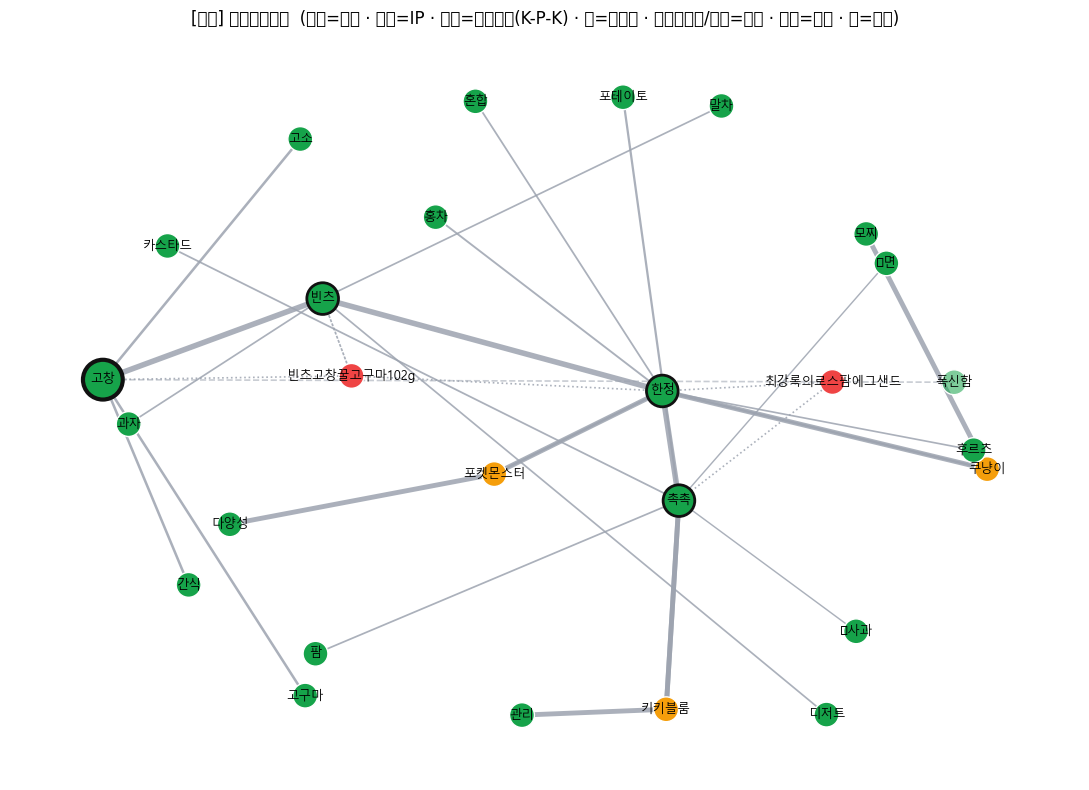

In [59]:
# 3.8a 서브네트워크 — 레일(척추) + 1-hop 타입별 문맥(IP/트렌드/바스켓) + IP 2-hop + 잠식
from src.eval.md import subnet as SN
net = SN.build_subnetwork(eng, SEED, eps=0.02, max_hops=4, sc=SC)   # SC 공유 → combo_grow 재계산 안 함
from collections import Counter
print(f"[{SEED}] 노드 {len(net['nodes'])} 엣지 {len(net['edges'])} | 타입 {dict(Counter(n['type'] for n in net['nodes']))}")
print("레일:", " ➔ ".join(net["rail"]))
SN.draw_subnetwork(net)

① recommend_within(고창) — 서브네트 내 붙이면 좋은 노드:


,keyword,margin,label
0,빈츠,0.1131,✅보강
1,한정,0.1030,✅보강
2,촉촉,0.0838,✅보강
3,말차,0.0610,✅보강
4,후르츠,0.0301,✅보강
5,고소,0.0291,✅보강


② pair_synergy(고창, 한정): {'a': '고창', 'b': '한정', 'synergy': 0.0141, 'margin_b_given_a': 0.103, 'margin_b_alone': 0.0889, 'label': '✅보완(synergy>0)'}
③ best_path(고창, 한정):
   경로: 고창 → 빈츠 → 한정
   끝점 시너지: ⚠대체/잠식 -0.0073


c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\src\eval\md\subnet.py:391: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  ax.axis("off"); plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projec

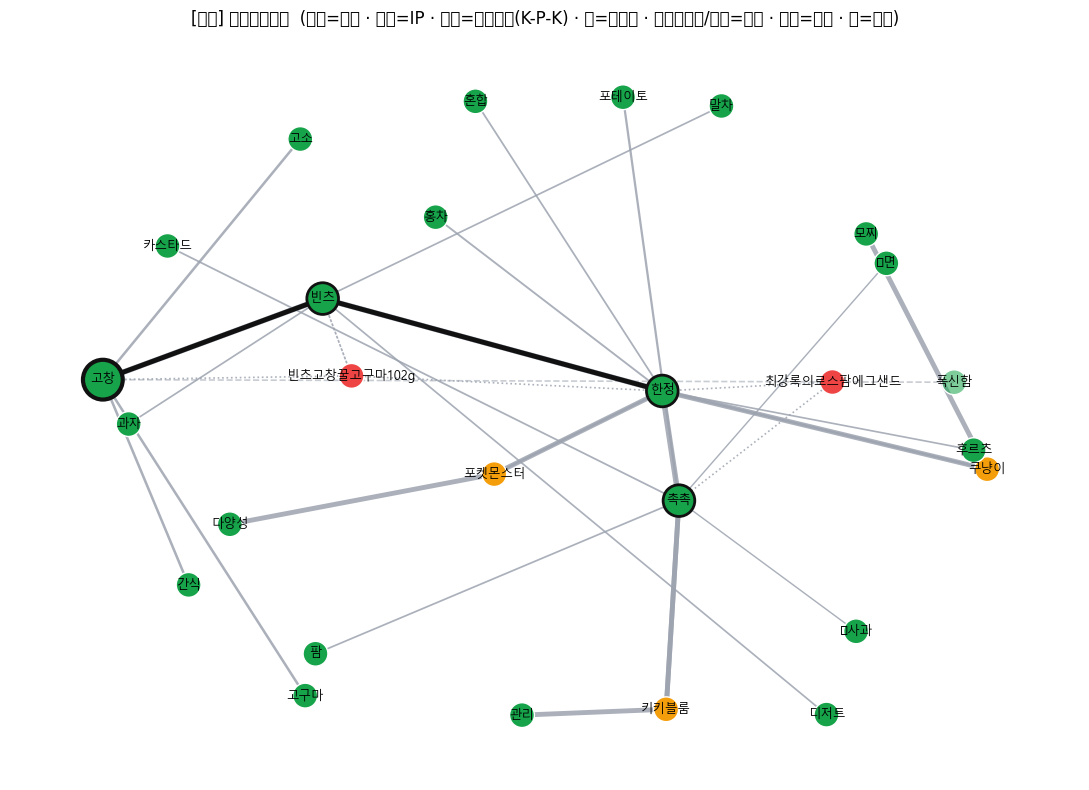

In [60]:
# 3.8b 상호작용 — ① 시작노드 추천  ② 두 노드 시너지  ③ 두 노드 최적 패스
pool = [n["label"] for n in net["nodes"] if n["type"] in ("rail", "trend", "basket", "ip2")]

print(f"① recommend_within({SEED}) — 서브네트 내 붙이면 좋은 노드:")
display(SN.recommend_within(eng, SEED, pool, n_headroom=10, top=6, sc=SC))

A, B = SEED, net["rail"][2] if len(net["rail"]) > 2 else net["rail"][-1]   # 예: 마라 vs 짭조름함
print(f"② pair_synergy({A}, {B}):", SN.pair_synergy(eng, A, B, n_headroom=10, sc=SC))

print(f"③ best_path({A}, {B}):")
bp = SN.best_path(eng, A, B, net, sc=SC)
print("   경로:", " → ".join(bp["path"]) if bp.get("path") else f"직접경로 없음 → 글루 {bp.get('glue')}")
print("   끝점 시너지:", bp["synergy"]["label"], bp["synergy"]["synergy"])
SN.draw_subnetwork(net, highlight_path=bp.get("path"))   # 패스 강조해 다시 그림

## 4. 확정 export → keyword_final.csv

In [61]:
# §4 확정 export — 3유형 + grade(T1/T2) + 증거 풀세트 keyword_final.csv
exp = df_kw[["keyword", "tag", "grade", "빈도", "purity", "woe", "att_lift", "supp_s", "supp_f"]].copy()
exp.loc[exp.tag == "hub", "tag"] = "neutral"; exp.loc[exp.tag == "neutral", "grade"] = ""   # hub=내부게이트
if "med" in dir() and len(med):
    mg = med.set_index("keyword")["grade"]
    is_med = exp.keyword.isin(med["keyword"]) & (exp.tag == "neutral")
    exp.loc[is_med, "tag"] = "매개"
    exp.loc[is_med, "grade"] = exp.loc[is_med, "keyword"].map(mg)
exp["include"] = "Y"

# 증거 merge — killer(kdf)·mine(mdf)·매개(med) (Δ 재계산 안 함)
_k = kdf[["keyword", "단독성공률", "delta", "delta_cond", "판정", "예시제품"]]
_m = mdf[["keyword", "단독성공률", "delta", "판정", "예시제품"]]
_e = med[["keyword", "단독성공률", "delta_mean", "delta_pos", "예시제품"]].rename(columns={"delta_mean": "delta"})
_e["판정"] = "매개"
ev_all = pd.concat([_k, _m, _e], ignore_index=True, sort=False).drop_duplicates("keyword")
exp = exp.merge(ev_all, on="keyword", how="left")
exp["suggested"] = np.where(exp["판정"] == "가짜(강등)", "강등검토(Δ≤0)", np.where(exp.tag == "killer", "유지", ""))

cols = ["keyword", "tag", "grade", "include", "빈도", "purity", "woe", "단독성공률",
        "delta", "delta_cond", "delta_pos", "판정", "suggested", "예시제품"]
path = "data/processed/hin/keyword_final.csv"
exp[[c for c in cols if c in exp.columns]].to_csv(path, index=False, encoding="utf-8-sig")
print("저장:", path, "|", len(exp), "키워드")
g = exp[exp.tag != "neutral"].groupby(["tag", "grade"]).size()
print("3유형×등급:"); print(g.to_string())
print(f"출력 합 = {int((exp.tag!='neutral').sum())}")

저장: data/processed/hin/keyword_final.csv | 2063 키워드
3유형×등급:
tag     grade
killer  T1       33
        T2       91
mine    T1       70
매개      T1       24
        T2       55
출력 합 = 273


## 5. 대시보드 연결 (확정 후)
CSV 확정(include/tag 편집) 후 터미널에서:
```
python -m scripts.export_dashboard
```
→ `Dashboard/config.js` 재생성 → `dashboard.html` 열면 확정 키워드·태그(색) 반영. **코드 수정 없음.**

## 6. MD 서빙 미리보기 — 확정 → 대시보드/MD 한 눈에

이 노트북에서 확정한 것(`keyword_final.csv` include/tag + `combo_final.csv` 파트너)이 `serve.py`를 통해 대시보드·MD 처방으로 나가는 모습을 바로 확인한다. (서빙 모델 = `v2_sweepA`)

In [ ]:
# 서빙 미리보기 — 확정 결과(keyword_final.csv)가 대시보드/MD에 어떻게 나가나
from src.eval import serve
serve._data.cache_clear()   # keyword_final.csv 갱신분 반영
d = serve._data()
PREVIEW_TREND = "마라"
attrs = serve.infer_attrs(PREVIEW_TREND)
net = serve._keyword_net(PREVIEW_TREND, d)
tagged = [n for n in net["nodes"] if n.get("tag")]
print(f"서빙 모델: {serve.SERVING_EXP}")
print(f"[{PREVIEW_TREND}] 추론 속성({len(attrs)}): {attrs[:8]}")
print(f"네트워크: 노드 {len(net['nodes'])} · 엣지 {len(net['edges'])} · tag(killer/mine/hub) 부착 {len(tagged)}")
print("→ include=N 키워드는 그래프에서 빠지고, tag는 노드 색으로 대시보드에 반영됨.")
print("   (전체 MD 처방문은 md_prescription_pipeline.ipynb Stage 3 = get_md_prescription)")

서빙 모델: v2_sweepA
[마라] 추론 속성(9): ['감칠맛', '마라', '매콤', '술', '안주', '야식', '육수', '쫄깃함']
네트워크: 노드 41 · 엣지 40 · tag(killer/mine/hub) 부착 5
→ include=N 키워드는 그래프에서 빠지고, tag는 노드 색으로 대시보드에 반영됨.
   (전체 MD 처방문은 md_prescription_pipeline.ipynb Stage 3 = get_md_prescription)


## 부록 — 파라미터 검증 EDA (확정 근거)

§1.5의 파라미터/임계가 "임의값"이 아니라 **데이터 분포의 자연 경계**임을 보이는 검증 플롯. (`§1.5` 실행 후 globals: `purity_arr·supp_s·supp_f·supp_all·hub_score_arr·lg` 사용)
- balance 거리(eps=0.15) · 후보군별 Score 분포 · mine Score_fail gap(Q75=1.75) · Hub_Score ECDF(Q80).
- 결론: 5종 모두 분포 경계와 일치 → 값 확정. 상세 해설은 카톡 md 참조.

In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Balance 거리 분포 — eps 기준점 탐색')

c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects

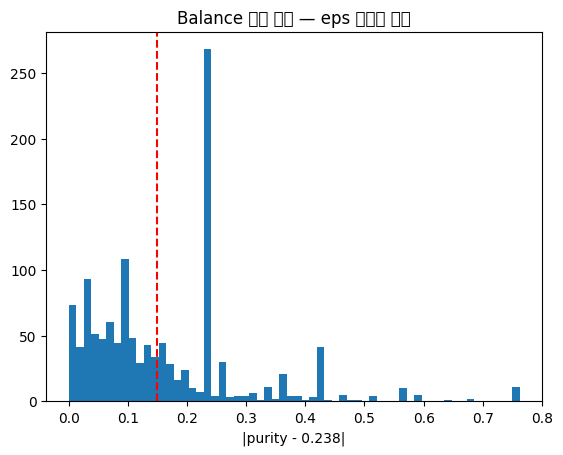

In [ ]:
balance_dist = np.abs(purity_arr[supp_all >= 3] - 0.238)
plt.hist(balance_dist, bins=60)
plt.axvline(0.15, color='red', ls='--', label='현재 eps=0.15')
plt.xlabel('|purity - 0.238|')
plt.title('Balance 거리 분포 — eps 기준점 탐색')


C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\1322634539.py:20: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\1322634539.py:20: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\1322634539.py:20: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing 

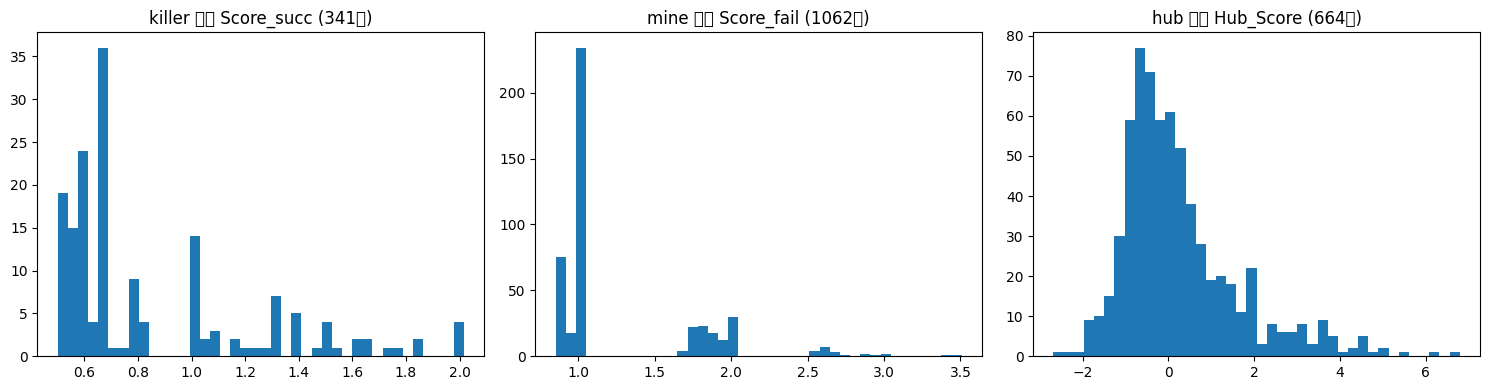

killer 후보: 167개
mine 후보:   458개
hub 후보:    664개


In [ ]:
# Step 1: 각 후보군의 Score 분포 확인 (10분)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# killer 후보군 (purity ≥ 0.50)
killer_cand = purity_arr >= 0.50
axes[0].hist(lg.score_succ[killer_cand & (supp_all>=3)], bins=40)
axes[0].set_title(f'killer 후보 Score_succ ({killer_cand.sum()}개)')

# mine 후보군 (purity ≤ 0.15)
mine_cand = purity_arr <= 0.15
axes[1].hist(lg.score_fail[mine_cand & (supp_all>=3)], bins=40)
axes[1].set_title(f'mine 후보 Score_fail ({mine_cand.sum()}개)')

# hub 후보군 (|purity-0.238| < 0.15)
hub_cand = np.abs(purity_arr - 0.238) < 0.15
axes[2].hist(hub_score_arr[hub_cand & (supp_all>=3)], bins=40)
axes[2].set_title(f'hub 후보 Hub_Score ({hub_cand.sum()}개)')

plt.tight_layout(); plt.show()
print(f"killer 후보: {(killer_cand & (supp_all>=3)).sum()}개")
print(f"mine 후보:   {(mine_cand   & (supp_all>=3)).sum()}개")
print(f"hub 후보:    {(hub_cand    & (supp_all>=3)).sum()}개")


C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\1844459292.py:15: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\1844459292.py:15: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\1844459292.py:15: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) mi

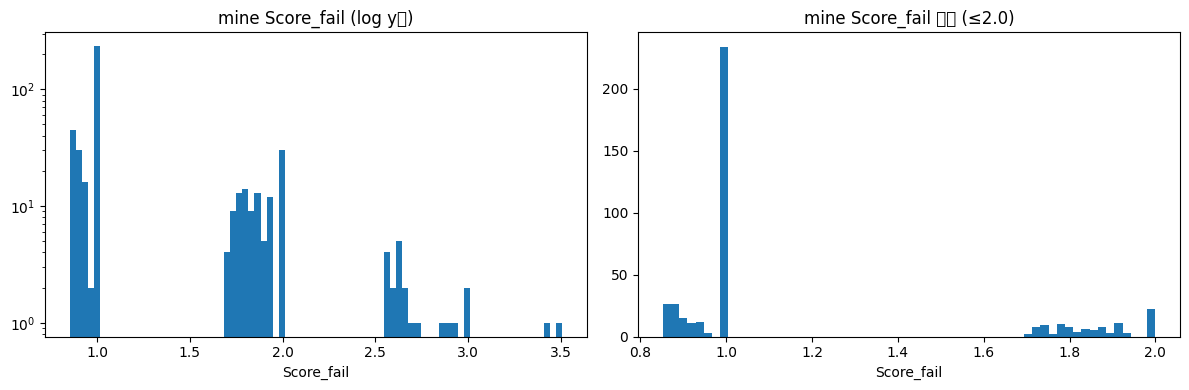

Q25 = 1.000  (355개)
Q50 = 1.000  (294개)
Q75 = 1.750  (115개)
Q90 = 2.000  (47개)
Q95 = 2.000  (23개)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mine_scores = lg.score_fail[mine_cand & (supp_all>=3)]

# log scale
axes[0].hist(mine_scores, bins=80, log=True)
axes[0].set_title('mine Score_fail (log y축)')
axes[0].set_xlabel('Score_fail')

# 1.0~2.0 구간 확대
axes[1].hist(mine_scores[mine_scores <= 2.0], bins=60)
axes[1].set_title('mine Score_fail 확대 (≤2.0)')
axes[1].set_xlabel('Score_fail')

plt.tight_layout(); plt.show()

# 분위수 확인
for q in [0.25, 0.50, 0.75, 0.90, 0.95]:
    print(f"Q{int(q*100):2d} = {np.quantile(mine_scores, q):.3f}  ({int((mine_scores >= np.quantile(mine_scores, q)).sum())}개)")


C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\3945399859.py:10: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\3945399859.py:10: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\송정현\AppData\Local\Temp\ipykernel_27812\3945399859.py:10: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


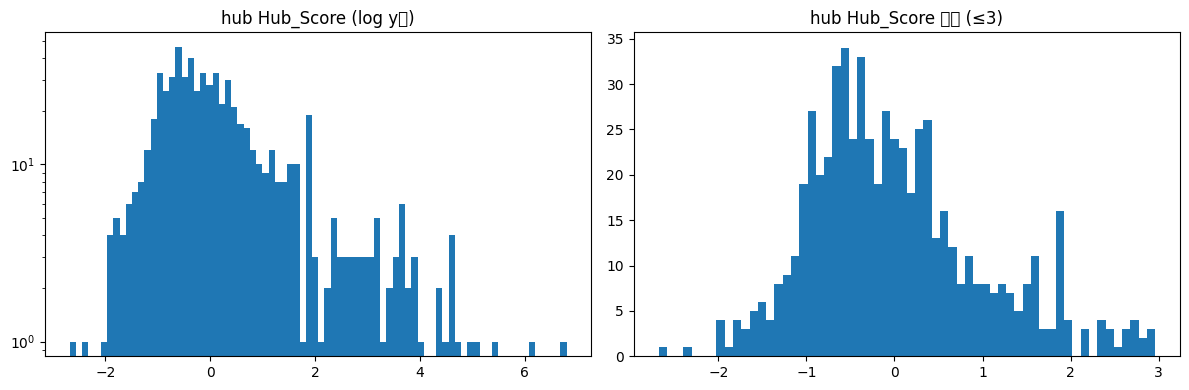

Q25 = -0.646  (498개)
Q50 = -0.075  (332개)
Q75 = 0.732  (166개)
Q90 = 1.925  (67개)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hub_scores = hub_score_arr[hub_cand & (supp_all>=3)]

axes[0].hist(hub_scores, bins=80, log=True)
axes[0].set_title('hub Hub_Score (log y축)')

axes[1].hist(hub_scores[hub_scores <= 3], bins=60)
axes[1].set_title('hub Hub_Score 확대 (≤3)')

plt.tight_layout(); plt.show()

for q in [0.25, 0.50, 0.75, 0.90]:
    print(f"Q{int(q*100):2d} = {np.quantile(hub_scores, q):.3f}  ({int((hub_scores >= np.quantile(hub_scores, q)).sum())}개)")


Text(0.5, 1.0, 'Hub_Score ECDF')

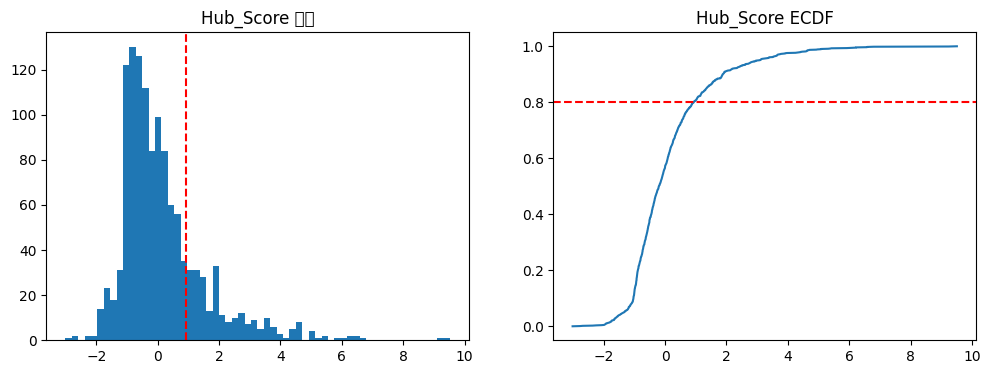

In [ ]:
hs = hub_score_arr[supp_all >= 3]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hs, bins=60)
axes[0].axvline(np.quantile(hs, 0.80), color='red', ls='--', label='현재 Q80')
axes[0].set_title('Hub_Score 분포')

# ECDF
axes[1].plot(np.sort(hs), np.linspace(0, 1, len(hs)))
axes[1].axhline(0.80, color='red', ls='--', label='Q80')
axes[1].set_title('Hub_Score ECDF')
